In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
!pip install ydata-profiling
from ydata_profiling import ProfileReport

Looking in indexes: https://nexus.iisys.de/repository/ki-awz-pypi-group/simple, https://pypi.org/simple
  Using cached ydata_profiling-4.18.4-py2.py3-none-any.whl.metadata (23 kB)
  Using cached matplotlib-3.10.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached minify_html-0.18.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (18 kB)
  Using cached filetype-1.2.0-py2.py3-none-any.whl.metadata (6.5 kB)
  Using cached phik-0.12.5-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached multimethod-1.12-py3-none-any.whl.metadata (9.6 kB)
  Using cached typeguard-4.5.2-py3-none-any.whl.metadata (3.8 kB)
  Using cached ImageHash-4.3.2-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached wordcloud-1.9.6-cp3

/tmp/ipykernel_135/3439640783.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
df=pd.read_csv("cleaned_data_all.csv")

In [3]:
df.columns

Index(['patient_info_id', 'headache', 'migraine', 'attack_time', 'duration',
       'symptoms_both_side_headache', 'symptoms_one_side_headache',
       'symptoms_pulsating_headache', 'symptoms_dull_headache', 'weekday',
       'date_registration', 'gender', 'birthyear', 'entries_app',
       'first_app_entry', 'last_app_entry', 'period_use_app',
       'headache_entries_app', 'migraine_entries_app', 'age', 'year', 'month'],
      dtype='object')

In [4]:
df.dtypes

patient_info_id                  int64
headache                          bool
migraine                          bool
attack_time                     object
duration                         int64
symptoms_both_side_headache       bool
symptoms_one_side_headache        bool
symptoms_pulsating_headache       bool
symptoms_dull_headache            bool
weekday                         object
date_registration               object
gender                          object
birthyear                        int64
entries_app                    float64
first_app_entry                 object
last_app_entry                  object
period_use_app                 float64
headache_entries_app           float64
migraine_entries_app           float64
age                              int64
year                             int64
month                            int64
dtype: object

In [5]:
df.head()

,patient_info_id,headache,migraine,attack_time,duration,symptoms_both_side_headache,symptoms_one_side_headache,symptoms_pulsating_headache,symptoms_dull_headache,weekday,...,birthyear,entries_app,first_app_entry,last_app_entry,period_use_app,headache_entries_app,migraine_entries_app,age,year,month
0,10007520,True,False,2023-06-21 00:00:00,900,True,False,True,False,Mittwoch,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6
1,10007520,True,False,2023-06-24 00:00:00,300,True,False,True,False,Samstag,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6
2,10007520,True,False,2023-06-25 00:00:00,480,True,False,True,False,Sonntag,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6
3,10007520,True,False,2023-06-26 00:00:00,300,True,False,True,False,Montag,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6
4,10007520,True,False,2023-06-27 00:00:00,900,True,False,True,True,Dienstag,...,1962,517.0,2023-06-21 00:00:00,2024-11-18 00:00:00,517.0,122.0,10.0,61,2023,6


In [6]:
df.isnull().any()

patient_info_id                False
headache                       False
migraine                       False
attack_time                    False
duration                       False
symptoms_both_side_headache    False
symptoms_one_side_headache     False
symptoms_pulsating_headache    False
symptoms_dull_headache         False
weekday                        False
date_registration              False
gender                         False
birthyear                      False
entries_app                    False
first_app_entry                False
last_app_entry                 False
period_use_app                 False
headache_entries_app           False
migraine_entries_app           False
age                            False
year                           False
month                          False
dtype: bool

In [7]:
cols = ["attack_time","date_registration","first_app_entry","last_app_entry"]

df[cols] = df[cols].apply(pd.to_datetime, errors="coerce")

In [8]:
df.dtypes

patient_info_id                         int64
headache                                 bool
migraine                                 bool
attack_time                    datetime64[ns]
duration                                int64
symptoms_both_side_headache              bool
symptoms_one_side_headache               bool
symptoms_pulsating_headache              bool
symptoms_dull_headache                   bool
weekday                                object
date_registration              datetime64[ns]
gender                                 object
birthyear                               int64
entries_app                           float64
first_app_entry                datetime64[ns]
last_app_entry                 datetime64[ns]
period_use_app                        float64
headache_entries_app                  float64
migraine_entries_app                  float64
age                                     int64
year                                    int64
month                             

In [9]:
df.head()

,patient_info_id,headache,migraine,attack_time,duration,symptoms_both_side_headache,symptoms_one_side_headache,symptoms_pulsating_headache,symptoms_dull_headache,weekday,...,birthyear,entries_app,first_app_entry,last_app_entry,period_use_app,headache_entries_app,migraine_entries_app,age,year,month
0,10007520,True,False,2023-06-21,900,True,False,True,False,Mittwoch,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6
1,10007520,True,False,2023-06-24,300,True,False,True,False,Samstag,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6
2,10007520,True,False,2023-06-25,480,True,False,True,False,Sonntag,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6
3,10007520,True,False,2023-06-26,300,True,False,True,False,Montag,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6
4,10007520,True,False,2023-06-27,900,True,False,True,True,Dienstag,...,1962,517.0,2023-06-21,2024-11-18,517.0,122.0,10.0,61,2023,6


In [10]:
attacks_over_time = df.groupby("attack_time").size()

In [11]:
attacks_over_time

attack_time
2020-06-22       1
2020-06-25       1
2020-06-26       1
2020-06-27       1
2020-06-29       1
              ... 
2026-02-11    1044
2026-02-12    1001
2026-02-13    1000
2026-02-14     966
2026-02-15     887
Length: 2062, dtype: int64

<Axes: xlabel='attack_time'>

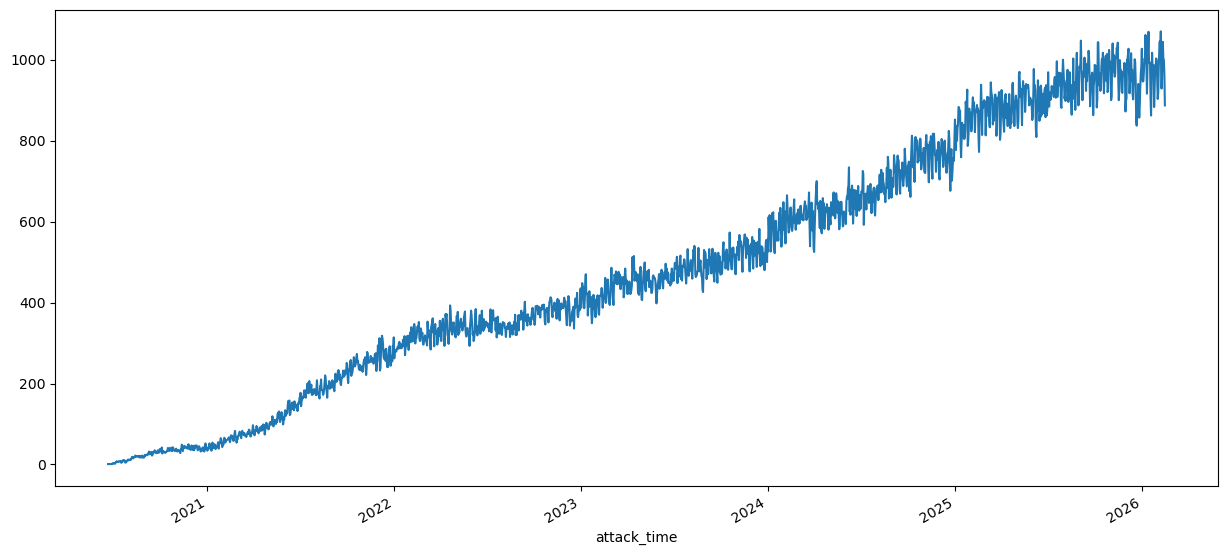

In [12]:
attacks_over_time.plot(figsize=(15,7))
#but this can also mean that the number of app users increased over time,
#this does not mean attacks increased over time but it means more users were recorded

In [13]:
#so lets try something new , attacks per active patient,  it removes user growth bias
daily_attacks = df.groupby("attack_time").size()
daily_users = df.groupby("attack_time")["patient_info_id"].nunique()
attack_rate = daily_attacks / daily_users

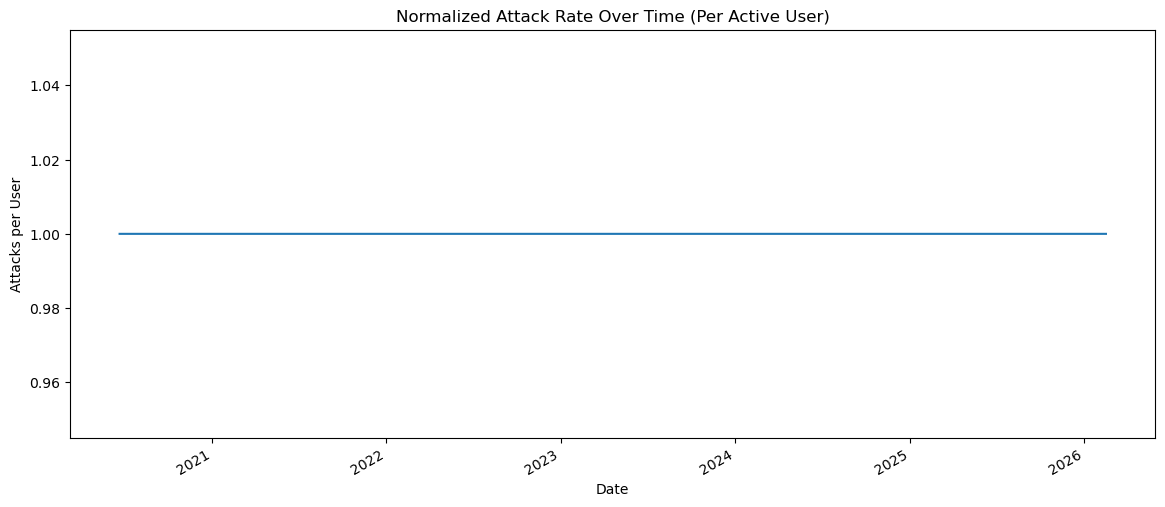

In [14]:
plt.figure(figsize=(14,6))

attack_rate.plot()

plt.title("Normalized Attack Rate Over Time (Per Active User)")
plt.xlabel("Date")
plt.ylabel("Attacks per User")

plt.show()

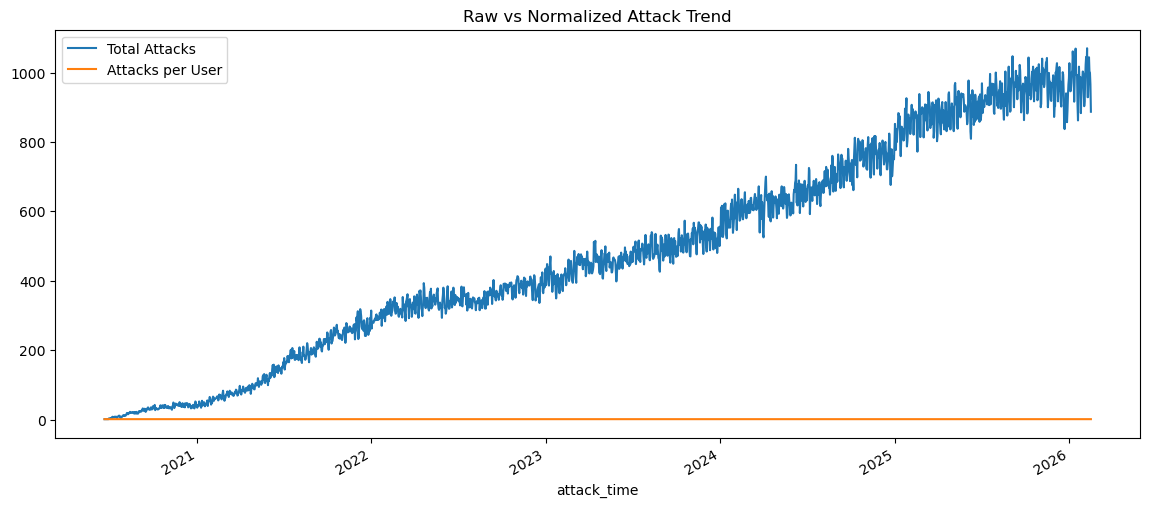

In [15]:
plt.figure(figsize=(14,6))

daily_attacks.plot(label="Total Attacks")
attack_rate.plot(label="Attacks per User")

plt.legend()
plt.title("Raw vs Normalized Attack Trend")
plt.show()

In [16]:
#lets analyse the patient we have per year
patients_per_year = df.groupby("year")["patient_info_id"].nunique()

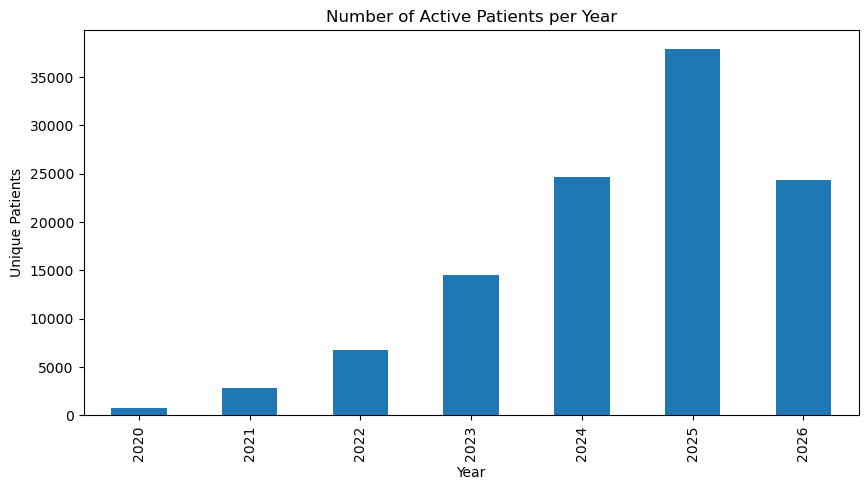

In [17]:
patients_per_year.plot(kind="bar", figsize=(10,5))

plt.title("Number of Active Patients per Year")
plt.xlabel("Year")
plt.ylabel("Unique Patients")

plt.show()

In [18]:
#lets see the number of attacks per year
attacks_per_year = df.groupby("year").size()
#rate of attack per year
attack_rate_per_year = attacks_per_year / patients_per_year

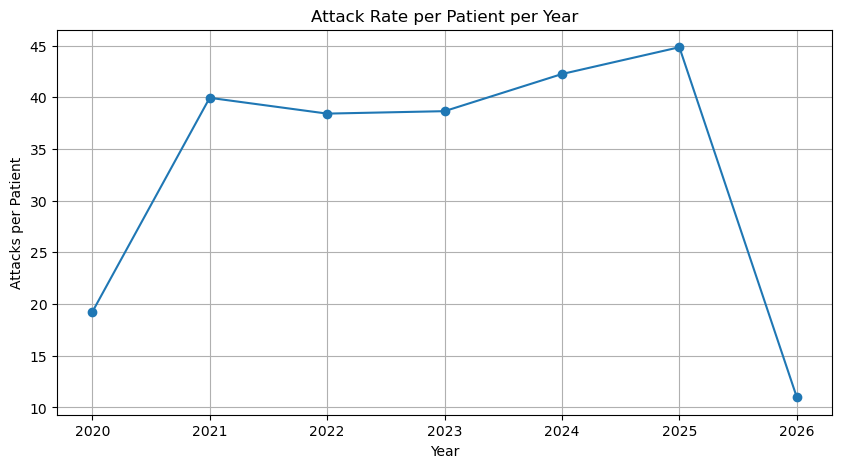

In [19]:
plt.figure(figsize=(10,5))

attack_rate_per_year.plot(marker="o")

plt.title("Attack Rate per Patient per Year")
plt.xlabel("Year")
plt.ylabel("Attacks per Patient")

plt.grid(True)
plt.show()

In [20]:
weekdays= df["weekday"].value_counts()

<Axes: xlabel='weekday'>

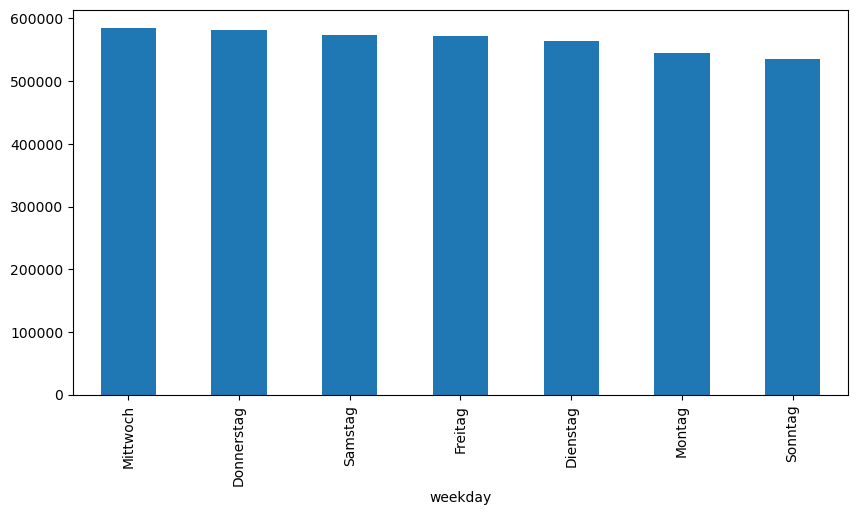

In [21]:
weekdays.plot(kind="bar", figsize=(10,5))

In [22]:
months=df["month"].value_counts().sort_index()

<Axes: xlabel='month'>

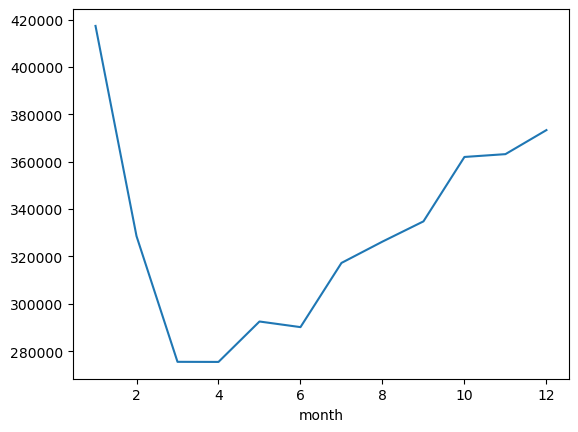

In [23]:
months.plot()

In [24]:
df["month"].dtypes

dtype('int64')

In [25]:
# actual normalization start here   finding the earliest and latest dates and number of months the attacks were registered each year

In [26]:
#min and max date
print(df["attack_time"].min())
print(df["attack_time"].max())

2020-06-22 00:00:00
2026-02-15 00:00:00


In [27]:
df.groupby("year")["month"].nunique()

year
2020     7
2021    12
2022    12
2023    12
2024    12
2025    12
2026     2
Name: month, dtype: int64

In [28]:
# now the actual analysis will start

In [29]:
df = df[(df["year"] != 2026) & (df["year"] != 2020)]

In [30]:
df["year"].value_counts().sort_index()

year
2021     113602
2022     258429
2023     559229
2024    1041526
2025    1701943
Name: count, dtype: int64

In [31]:
all_days = pd.date_range(
    start=df["attack_time"].min(),
    end=df["attack_time"].max(),
    freq="D"
)

In [32]:
len(all_days)

1826

In [33]:
all_days

DatetimeIndex(['2021-01-01', '2021-01-02', '2021-01-03', '2021-01-04',
               '2021-01-05', '2021-01-06', '2021-01-07', '2021-01-08',
               '2021-01-09', '2021-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=1826, freq='D')

In [34]:
daily_attacks = df.groupby("attack_time").size()

In [35]:
daily_attacks.head()

attack_time
2021-01-01    42
2021-01-02    34
2021-01-03    39
2021-01-04    40
2021-01-05    39
dtype: int64

In [36]:
daily_attacks = daily_attacks.reindex(
    all_days,
    fill_value=0
)

In [37]:
daily_attacks.head()

2021-01-01    42
2021-01-02    34
2021-01-03    39
2021-01-04    40
2021-01-05    39
Freq: D, dtype: int64

In [38]:
day = pd.Timestamp("2021-01-01")

In [39]:
active = (
    (df["first_app_entry"] <= day) &
    (df["last_app_entry"] >= day)
)

In [40]:
#condition on the columns and the rows
n_active = df.loc[active, "patient_info_id"].nunique()

In [41]:
n_active

114

In [42]:
daily_participants = []

for day in all_days:
    
    active = (
        (df["first_app_entry"] <= day) &
        (df["last_app_entry"] >= day)
    )
    
    n_active = df.loc[
        active,
        "patient_info_id"
    ].nunique()
    
    daily_participants.append(n_active)

In [43]:
daily_participants

[114,
 114,
 114,
 115,
 115,
 116,
 116,
 118,
 118,
 120,
 122,
 124,
 125,
 126,
 126,
 127,
 130,
 129,
 129,
 130,
 132,
 132,
 134,
 134,
 135,
 135,
 136,
 138,
 138,
 138,
 139,
 147,
 147,
 150,
 152,
 153,
 154,
 157,
 158,
 162,
 164,
 165,
 165,
 165,
 167,
 168,
 170,
 172,
 172,
 172,
 174,
 174,
 175,
 178,
 179,
 179,
 182,
 183,
 185,
 190,
 191,
 195,
 197,
 198,
 198,
 198,
 200,
 202,
 204,
 204,
 205,
 207,
 207,
 207,
 208,
 209,
 210,
 212,
 212,
 213,
 214,
 214,
 215,
 216,
 216,
 218,
 220,
 223,
 223,
 226,
 228,
 232,
 231,
 232,
 233,
 236,
 237,
 238,
 240,
 240,
 241,
 242,
 244,
 245,
 245,
 248,
 249,
 252,
 251,
 253,
 253,
 255,
 256,
 257,
 258,
 264,
 264,
 265,
 265,
 267,
 272,
 274,
 282,
 288,
 294,
 298,
 303,
 304,
 309,
 314,
 316,
 321,
 323,
 326,
 327,
 330,
 337,
 339,
 342,
 343,
 346,
 350,
 354,
 357,
 361,
 363,
 365,
 367,
 367,
 368,
 375,
 384,
 386,
 386,
 389,
 392,
 394,
 399,
 405,
 409,
 412,
 413,
 417,
 418,
 426,
 430,
 435

In [44]:
len(daily_participants)

1826

In [45]:
daily_participants = pd.Series(
    daily_participants,
    index=all_days
)

In [46]:
daily_participants.head()

2021-01-01    114
2021-01-02    114
2021-01-03    114
2021-01-04    115
2021-01-05    115
Freq: D, dtype: int64

In [47]:
daily_attacks.index = pd.to_datetime(daily_attacks.index)
daily_participants.index = pd.to_datetime(daily_participants.index)

In [48]:
daily_rate = daily_attacks / daily_participants

In [49]:
daily_rate.head()

2021-01-01    0.368421
2021-01-02    0.298246
2021-01-03    0.342105
2021-01-04    0.347826
2021-01-05    0.339130
Freq: D, dtype: float64

In [50]:
daily_rate.isna().sum()

np.int64(0)

In [51]:
daily_rate.describe()   #What i now have is:Incidence intensity per active user per day 
                       #This is MUCH better than raw counts because it corrects for: changing user baseapp growth varying participation*/

count    1826.000000
mean        0.290355
std         0.032316
min         0.227564
25%         0.268876
50%         0.284312
75%         0.304188
max         0.471014
dtype: float64

In [52]:
monthly_rate  = daily_rate.resample("ME").mean()
print(monthly_rate)


2021-01-31    0.363879
2021-02-28    0.378409
2021-03-31    0.358865
2021-04-30    0.356573
2021-05-31    0.330591
2021-06-30    0.327046
2021-07-31    0.335220
2021-08-31    0.310010
2021-09-30    0.316984
2021-10-31    0.318745
2021-11-30    0.308432
2021-12-31    0.307767
2022-01-31    0.309966
2022-02-28    0.314817
2022-03-31    0.300909
2022-04-30    0.301481
2022-05-31    0.289254
2022-06-30    0.279590
2022-07-31    0.276892
2022-08-31    0.266378
2022-09-30    0.278311
2022-10-31    0.275419
2022-11-30    0.274247
2022-12-31    0.261581
2023-01-31    0.267818
2023-02-28    0.265854
2023-03-31    0.278043
2023-04-30    0.270539
2023-05-31    0.261544
2023-06-30    0.260413
2023-07-31    0.264480
2023-08-31    0.261919
2023-09-30    0.260816
2023-10-31    0.258850
2023-11-30    0.264271
2023-12-31    0.253718
2024-01-31    0.271462
2024-02-29    0.276991
2024-03-31    0.274937
2024-04-30    0.272612
2024-05-31    0.268466
2024-06-30    0.271758
2024-07-31    0.269691
2024-08-31 

In [53]:
yearly_rate   = daily_rate.resample("YE").mean()
print(yearly_rate)


2021-12-31    0.334093
2022-12-31    0.285524
2023-12-31    0.264007
2024-12-31    0.274356
2025-12-31    0.293838
Freq: YE-DEC, dtype: float64


In [54]:
weekly_rate   = daily_rate.groupby(daily_rate.index.dayofweek).mean()
print(weekly_rate)

0    0.277998
1    0.288701
2    0.298279
3    0.298480
4    0.296440
5    0.295135
6    0.277481
dtype: float64


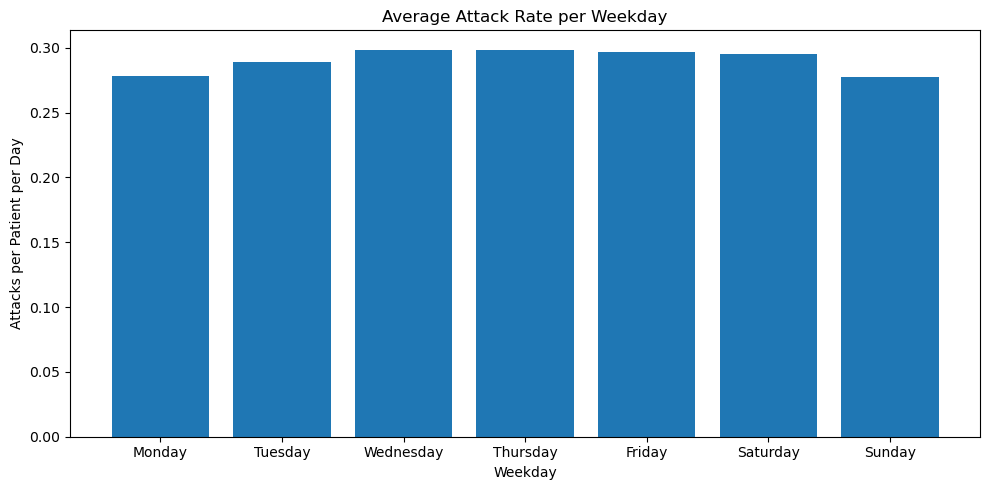

In [76]:
#weeekly pattern


import matplotlib.pyplot as plt

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
plt.bar(days, weekly_rate)
plt.title('Average Attack Rate per Weekday')
plt.xlabel('Weekday')
plt.ylabel('Attacks per Patient per Day')
plt.tight_layout()
plt.show()

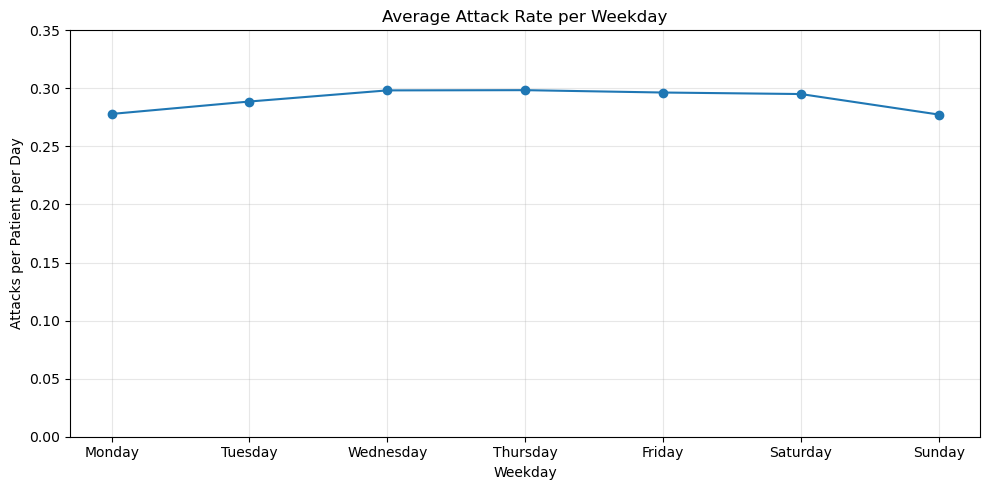

In [82]:
import matplotlib.pyplot as plt

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
plt.plot(days, weekly_rate, marker='o')
plt.title('Average Attack Rate per Weekday')
plt.xlabel('Weekday')
plt.ylabel('Attacks per Patient per Day')
plt.grid(True, alpha=0.3)
plt.ylim(0,0.35)
plt.tight_layout()
plt.show()

In [57]:
from scipy import stats

# get all daily rates grouped by weekday
groups = [daily_rate[daily_rate.index.dayofweek == day].values 
          for day in range(7)]

# kruskal wallis test
stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.4f}, p={p:.4f}")

Kruskal-Wallis H=164.5172, p=0.0000


In [58]:
pip install scikit-posthocs

Looking in indexes: https://nexus.iisys.de/repository/ki-awz-pypi-group/simple, https://pypi.org/simple
  Using cached scikit_posthocs-0.14.0-py3-none-any.whl.metadata (5.9 kB)
Using cached scikit_posthocs-0.14.0-py3-none-any.whl (36 kB)
Note: you may need to restart the kernel to use updated packages.


In [59]:
import scikit_posthocs as sp

dunn = sp.posthoc_dunn(
    [daily_rate[daily_rate.index.dayofweek == day].values 
     for day in range(7)],
    p_adjust='bonferroni'
)

dunn.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dunn.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print(dunn)

              Mon       Tue           Wed           Thu           Fri  \
Mon  1.000000e+00  0.000055  2.955308e-15  6.646906e-14  4.164844e-12   
Tue  5.541636e-05  1.000000  7.582204e-03  2.970926e-02  1.676249e-01   
Wed  2.955308e-15  0.007582  1.000000e+00  1.000000e+00  1.000000e+00   
Thu  6.646906e-14  0.029709  1.000000e+00  1.000000e+00  1.000000e+00   
Fri  4.164844e-12  0.167625  1.000000e+00  1.000000e+00  1.000000e+00   
Sat  2.816103e-11  0.351015  1.000000e+00  1.000000e+00  1.000000e+00   
Sun  1.000000e+00  0.000011  1.938821e-16  4.926970e-15  3.642148e-13   

              Sat           Sun  
Mon  2.816103e-11  1.000000e+00  
Tue  3.510155e-01  1.107311e-05  
Wed  1.000000e+00  1.938821e-16  
Thu  1.000000e+00  4.926970e-15  
Fri  1.000000e+00  3.642148e-13  
Sat  1.000000e+00  2.671886e-12  
Sun  2.671886e-12  1.000000e+00  


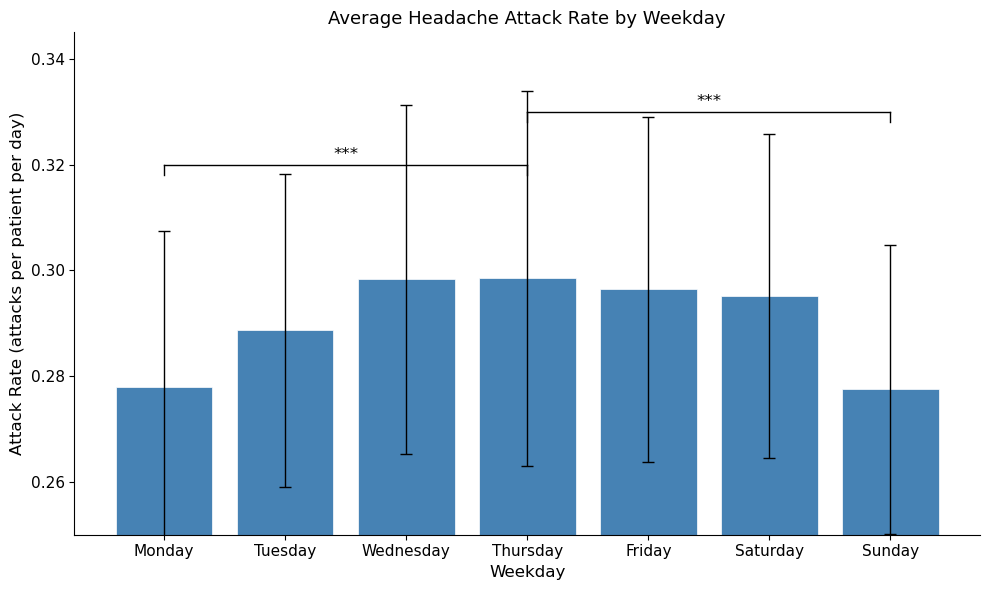

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# calculate mean and std per weekday across all days
weekly_mean = daily_rate.groupby(daily_rate.index.dayofweek).mean()
weekly_std = daily_rate.groupby(daily_rate.index.dayofweek).std()

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
        'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 6))

# bar chart with error bars
bars = ax.bar(days, weekly_mean.values,
              yerr=weekly_std.values,
              capsize=4,
              color='steelblue',
              edgecolor='white',
              linewidth=0.5,
              error_kw={'linewidth': 1, 'color': 'gray'})

# significance brackets
# Mon vs Thu (most significant pair)
y_max = 0.320
ax.plot([0, 3], [y_max, y_max], color='black', linewidth=1)
ax.plot([0, 0], [y_max - 0.002, y_max], color='black', linewidth=1)
ax.plot([3, 3], [y_max - 0.002, y_max], color='black', linewidth=1)
ax.text(1.5, y_max + 0.001, '***', ha='center', fontsize=12)

# Sun vs Thu
y_max2 = 0.330
ax.plot([3, 6], [y_max2, y_max2], color='black', linewidth=1)
ax.plot([3, 3], [y_max2 - 0.002, y_max2], color='black', linewidth=1)
ax.plot([6, 6], [y_max2 - 0.002, y_max2], color='black', linewidth=1)
ax.text(4.5, y_max2 + 0.001, '***', ha='center', fontsize=12)

# axis formatting
ax.set_ylim(0.25, 0.345)
ax.set_xlabel('Weekday', fontsize=12)
ax.set_ylabel('Attack Rate (attacks per patient per day)', fontsize=12)
ax.set_title('Average Headache Attack Rate by Weekday', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()

In [61]:
monthly_mean = daily_rate.groupby(daily_rate.index.month).mean()
monthly_std = daily_rate.groupby(daily_rate.index.month).std()
print(monthly_mean)

1     0.301326
2     0.306187
3     0.301029
4     0.298290
5     0.288505
6     0.284754
7     0.287900
8     0.279969
9     0.286241
10    0.287665
11    0.285787
12    0.277828
dtype: float64


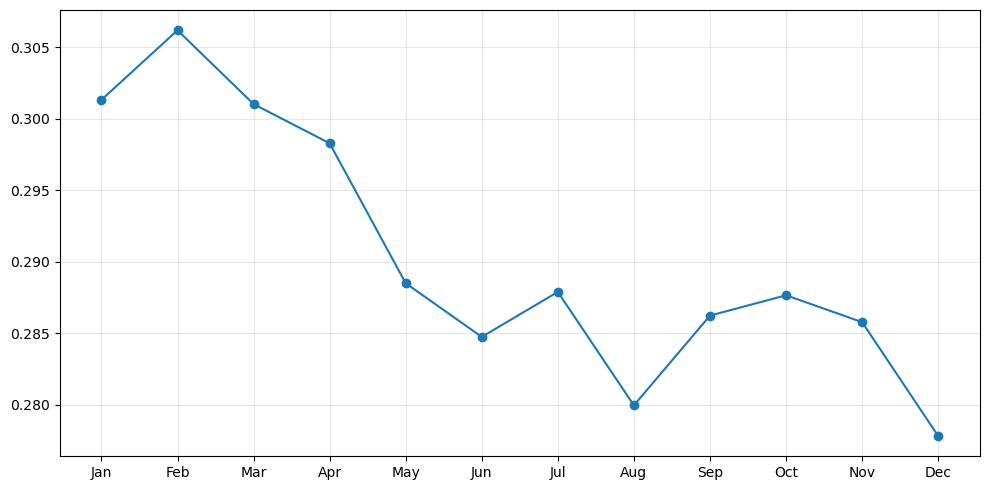

In [62]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(10, 5))
plt.plot(months, monthly_mean.values, marker='o')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [63]:
groups = [daily_rate[daily_rate.index.month == month].values 
          for month in range(1, 13)]

stat, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H={stat:.4f}, p={p:.4f}")

Kruskal-Wallis H=100.4815, p=0.0000


In [64]:
dunn_monthly = sp.posthoc_dunn(
    [daily_rate[daily_rate.index.month == month].values 
     for month in range(1, 13)],
    p_adjust='bonferroni'
)

dunn_monthly.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                       'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
dunn_monthly.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(dunn_monthly.round(4))

        Jan     Feb     Mar     Apr     May     Jun     Jul     Aug     Sep  \
Jan  1.0000  1.0000  1.0000  1.0000  0.5476  0.0040  0.1495  0.0000  0.4998   
Feb  1.0000  1.0000  1.0000  1.0000  0.0672  0.0003  0.0149  0.0000  0.0613   
Mar  1.0000  1.0000  1.0000  1.0000  0.0786  0.0003  0.0170  0.0000  0.0718   
Apr  1.0000  1.0000  1.0000  1.0000  1.0000  0.0364  0.8253  0.0003  1.0000   
May  0.5476  0.0672  0.0786  1.0000  1.0000  1.0000  1.0000  0.7586  1.0000   
Jun  0.0040  0.0003  0.0003  0.0364  1.0000  1.0000  1.0000  1.0000  1.0000   
Jul  0.1495  0.0149  0.0170  0.8253  1.0000  1.0000  1.0000  1.0000  1.0000   
Aug  0.0000  0.0000  0.0000  0.0003  0.7586  1.0000  1.0000  1.0000  0.9325   
Sep  0.4998  0.0613  0.0718  1.0000  1.0000  1.0000  1.0000  0.9325  1.0000   
Oct  1.0000  0.2633  0.3126  1.0000  1.0000  1.0000  1.0000  0.2140  1.0000   
Nov  0.5556  0.0695  0.0814  1.0000  1.0000  1.0000  1.0000  0.8438  1.0000   
Dec  0.0000  0.0000  0.0000  0.0000  0.0699  1.0000 

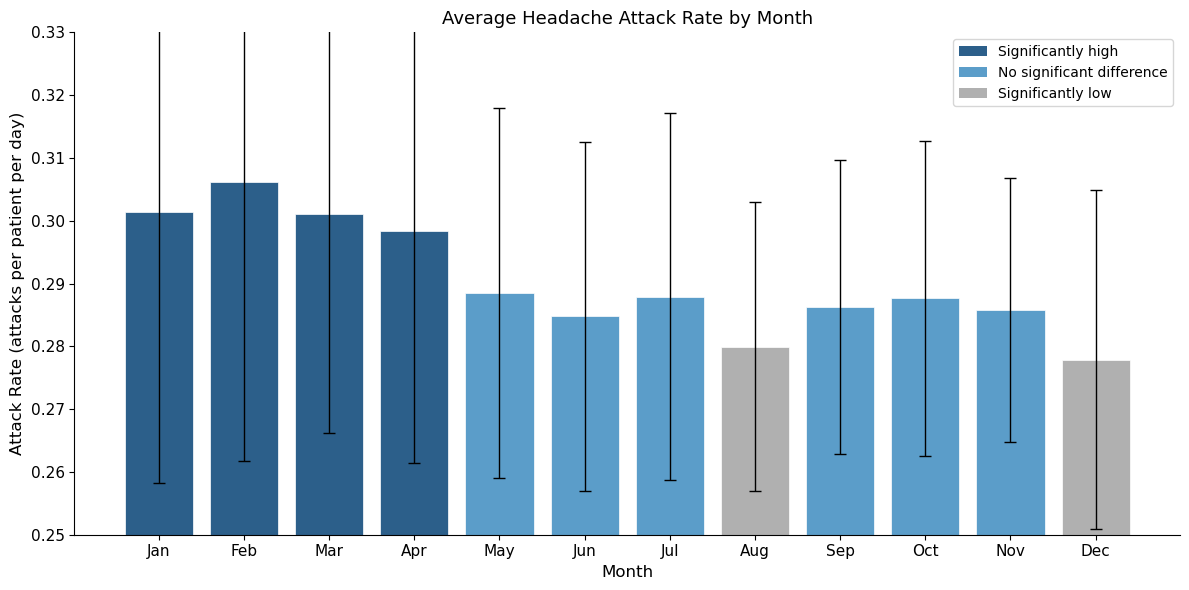

In [65]:
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

colors = ['#2c5f8a', '#2c5f8a', '#2c5f8a', '#2c5f8a',  # Jan-Apr dark blue
          '#5b9dc9', '#5b9dc9', '#5b9dc9',               # May-Jul medium blue
          '#b0b0b0',                                      # Aug gray
          '#5b9dc9', '#5b9dc9', '#5b9dc9',               # Sep-Nov medium blue
          '#b0b0b0']                                      # Dec gray

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(months, monthly_mean.values,
       yerr=monthly_std.values,
       capsize=4,
       color=colors,
       edgecolor='white',
       linewidth=0.5,
       error_kw={'linewidth': 1, 'color': 'gray'})

# legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2c5f8a', label='Significantly high'),
    Patch(facecolor='#5b9dc9', label='No significant difference'),
    Patch(facecolor='#b0b0b0', label='Significantly low')
]
ax.legend(handles=legend_elements, fontsize=10)

# axis formatting
ax.set_ylim(0.25, 0.330)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Attack Rate (attacks per patient per day)', fontsize=12)
ax.set_title('Average Headache Attack Rate by Month', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)

plt.tight_layout()
plt.show()

In [66]:
yearly_mean = daily_rate.groupby(daily_rate.index.year).mean()
yearly_std = daily_rate.groupby(daily_rate.index.year).std()
print(yearly_mean)

2021    0.334093
2022    0.285524
2023    0.264007
2024    0.274356
2025    0.293838
dtype: float64


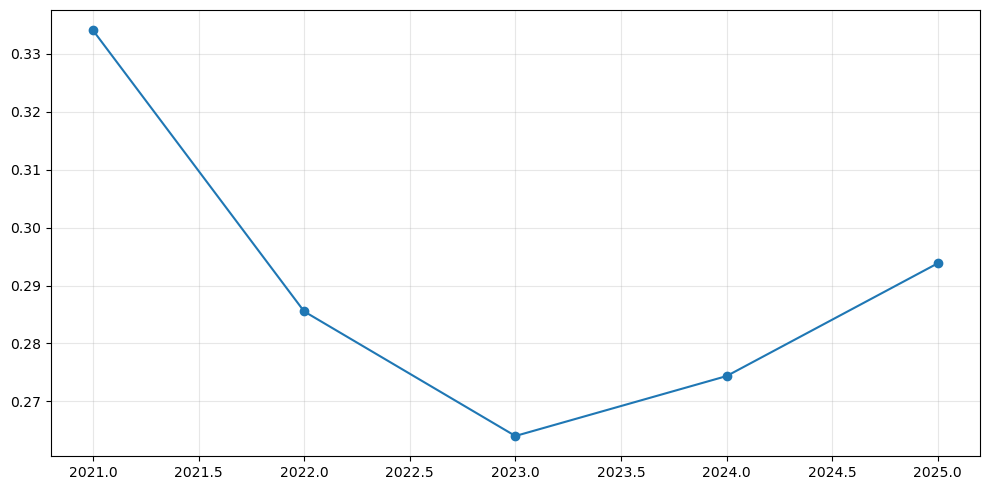

In [67]:
years = [2021, 2022, 2023, 2024, 2025]

plt.figure(figsize=(10, 5))
plt.plot(years, yearly_mean.values, marker='o')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [68]:
pip install pymannkendall

Looking in indexes: https://nexus.iisys.de/repository/ki-awz-pypi-group/simple, https://pypi.org/simple
  Using cached pymannkendall-1.4.3-py3-none-any.whl.metadata (14 kB)
Using cached pymannkendall-1.4.3-py3-none-any.whl (12 kB)
Note: you may need to restart the kernel to use updated packages.


In [69]:
import pymannkendall as mk

result = mk.original_test(yearly_mean.values)
print(f"Trend: {result.trend}")
print(f"p-value: {result.p:.4f}")
print(f"Tau: {result.Tau:.4f}")

Trend: no trend
p-value: 0.8065
Tau: -0.2000


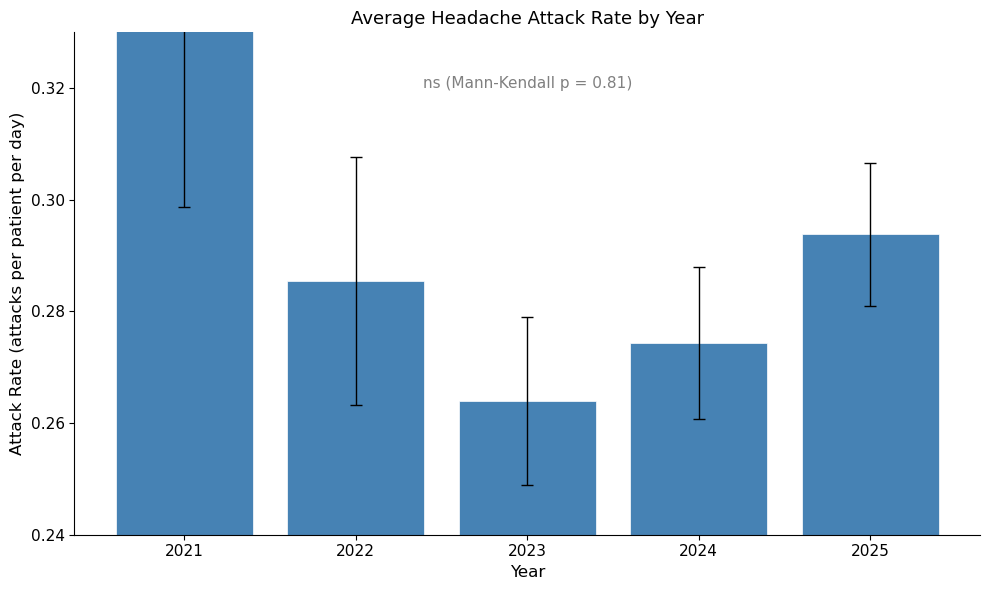

In [70]:
years = [2021, 2022, 2023, 2024, 2025]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(years, yearly_mean.values,
       yerr=yearly_std.values,
       capsize=4,
       color='steelblue',
       edgecolor='white',
       linewidth=0.5,
       error_kw={'linewidth': 1, 'color': 'gray'})

# add ns (not significant) text
ax.text(2023, 0.320, 'ns (Mann-Kendall p = 0.81)', 
        ha='center', fontsize=11, color='gray')

# axis formatting
ax.set_ylim(0.24, 0.330)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Attack Rate (attacks per patient per day)', fontsize=12)
ax.set_title('Average Headache Attack Rate by Year', fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=11)
ax.set_xticks(years)

plt.tight_layout()
plt.show()

In [71]:
# rename current results
weekly_mean_all = weekly_mean.copy()
weekly_std_all = weekly_std.copy()

monthly_mean_all = monthly_mean.copy()
monthly_std_all = monthly_std.copy()

yearly_mean_all = yearly_mean.copy()
yearly_std_all = yearly_std.copy()

daily_rate_all = daily_rate.copy()

In [72]:
# Step 1 - recreate split
attacks_per_month = (df.groupby(['patient_info_id', 'year', 'month'])
                      .size()
                      .reset_index(name='n_attacks'))

avg_attacks = (attacks_per_month.groupby('patient_info_id')['n_attacks']
                                .mean())

chronic_patients = avg_attacks[avg_attacks >= 15].index
episodic_patients = avg_attacks[avg_attacks < 15].index

# Step 2 - create and filter df_episodic
df_episodic = df[df['patient_info_id'].isin(episodic_patients)]
df_episodic = df_episodic[~df_episodic['year'].isin([2020, 2026])]

# Step 3 - complete date range
all_days_ep = pd.date_range(
    start=df_episodic['attack_time'].min(),
    end=df_episodic['attack_time'].max(),
    freq='D'
)

# Step 4 - daily attacks
daily_attacks_ep = df_episodic.groupby('attack_time').size()
daily_attacks_ep.index = pd.to_datetime(daily_attacks_ep.index)
daily_attacks_ep = daily_attacks_ep.reindex(all_days_ep, fill_value=0)

# Step 5 - daily participants loop
daily_participants_ep = []
for day in all_days_ep:
    active = (
        (df_episodic['first_app_entry'] <= day) &
        (df_episodic['last_app_entry'] >= day)
    )
    n_active = df_episodic.loc[active, 'patient_info_id'].nunique()
    daily_participants_ep.append(n_active)

daily_participants_ep = pd.Series(daily_participants_ep, index=all_days_ep)
daily_participants_ep.index = pd.to_datetime(daily_participants_ep.index)

# Step 6 - daily rate
daily_rate_ep = daily_attacks_ep / daily_participants_ep

# Step 7 - weekly monthly yearly
weekly_mean_ep = daily_rate_ep.groupby(daily_rate_ep.index.dayofweek).mean()
weekly_std_ep = daily_rate_ep.groupby(daily_rate_ep.index.dayofweek).std()

monthly_mean_ep = daily_rate_ep.groupby(daily_rate_ep.index.month).mean()
monthly_std_ep = daily_rate_ep.groupby(daily_rate_ep.index.month).std()

yearly_mean_ep = daily_rate_ep.groupby(daily_rate_ep.index.year).mean()
yearly_std_ep = daily_rate_ep.groupby(daily_rate_ep.index.year).std()

print("Weekly mean episodic:")
print(weekly_mean_ep)
print("\nMonthly mean episodic:")
print(monthly_mean_ep)
print("\nYearly mean episodic:")
print(yearly_mean_ep)

Weekly mean episodic:
0    0.203118
1    0.213991
2    0.224968
3    0.225873
4    0.223941
5    0.223505
6    0.204172
dtype: float64

Monthly mean episodic:
1     0.229041
2     0.232092
3     0.223503
4     0.222801
5     0.217144
6     0.214343
7     0.216143
8     0.208480
9     0.213598
10    0.213390
11    0.211592
12    0.203953
dtype: float64

Yearly mean episodic:
2021    0.258936
2022    0.221664
2023    0.200476
2024    0.200243
2025    0.204109
dtype: float64


In [73]:
from scipy import stats
import scikit_posthocs as sp
import pymannkendall as mk

# ── Weekly ────────────────────────────────────────────
groups_weekly_ep = [daily_rate_ep[daily_rate_ep.index.dayofweek == day].values 
                    for day in range(7)]
stat_w, p_w = stats.kruskal(*groups_weekly_ep)
print(f"Weekly Kruskal-Wallis H={stat_w:.4f}, p={p_w:.4f}")

# ── Monthly ───────────────────────────────────────────
groups_monthly_ep = [daily_rate_ep[daily_rate_ep.index.month == month].values 
                     for month in range(1, 13)]
stat_m, p_m = stats.kruskal(*groups_monthly_ep)
print(f"Monthly Kruskal-Wallis H={stat_m:.4f}, p={p_m:.4f}")

# ── Yearly ────────────────────────────────────────────
result_ep = mk.original_test(yearly_mean_ep.values)
print(f"Yearly Trend: {result_ep.trend}")
print(f"Yearly p-value: {result_ep.p:.4f}")
print(f"Yearly Tau: {result_ep.Tau:.4f}")

Weekly Kruskal-Wallis H=235.0084, p=0.0000
Monthly Kruskal-Wallis H=106.9290, p=0.0000
Yearly Trend: no trend
Yearly p-value: 0.2207
Yearly Tau: -0.6000


In [74]:
# ── Weekly Dunn ───────────────────────────────────────
dunn_weekly_ep = sp.posthoc_dunn(
    [daily_rate_ep[daily_rate_ep.index.dayofweek == day].values 
     for day in range(7)],
    p_adjust='bonferroni'
)

dunn_weekly_ep.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dunn_weekly_ep.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

print("Weekly Dunn test episodic:")
print(dunn_weekly_ep.round(4))

# ── Monthly Dunn ──────────────────────────────────────
dunn_monthly_ep = sp.posthoc_dunn(
    [daily_rate_ep[daily_rate_ep.index.month == month].values 
     for month in range(1, 13)],
    p_adjust='bonferroni'
)

dunn_monthly_ep.index = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
dunn_monthly_ep.columns = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print("\nMonthly Dunn test episodic:")
print(dunn_monthly_ep.round(4))

Weekly Dunn test episodic:
     Mon     Tue     Wed     Thu     Fri     Sat  Sun
Mon  1.0  0.0000  0.0000  0.0000  0.0000  0.0000  1.0
Tue  0.0  1.0000  0.0001  0.0002  0.0028  0.0006  0.0
Wed  0.0  0.0001  1.0000  1.0000  1.0000  1.0000  0.0
Thu  0.0  0.0002  1.0000  1.0000  1.0000  1.0000  0.0
Fri  0.0  0.0028  1.0000  1.0000  1.0000  1.0000  0.0
Sat  0.0  0.0006  1.0000  1.0000  1.0000  1.0000  0.0
Sun  1.0  0.0000  0.0000  0.0000  0.0000  0.0000  1.0

Monthly Dunn test episodic:
        Jan     Feb     Mar     Apr     May     Jun     Jul     Aug     Sep  \
Jan  1.0000  1.0000  1.0000  1.0000  0.3442  0.0073  0.0732  0.0000  0.3900   
Feb  1.0000  1.0000  1.0000  1.0000  0.0743  0.0011  0.0135  0.0000  0.0863   
Mar  1.0000  1.0000  1.0000  1.0000  0.2514  0.0048  0.0512  0.0000  0.2867   
Apr  1.0000  1.0000  1.0000  1.0000  1.0000  0.3011  1.0000  0.0027  1.0000   
May  0.3442  0.0743  0.2514  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000   
Jun  0.0073  0.0011  0.0048  0.3011  1

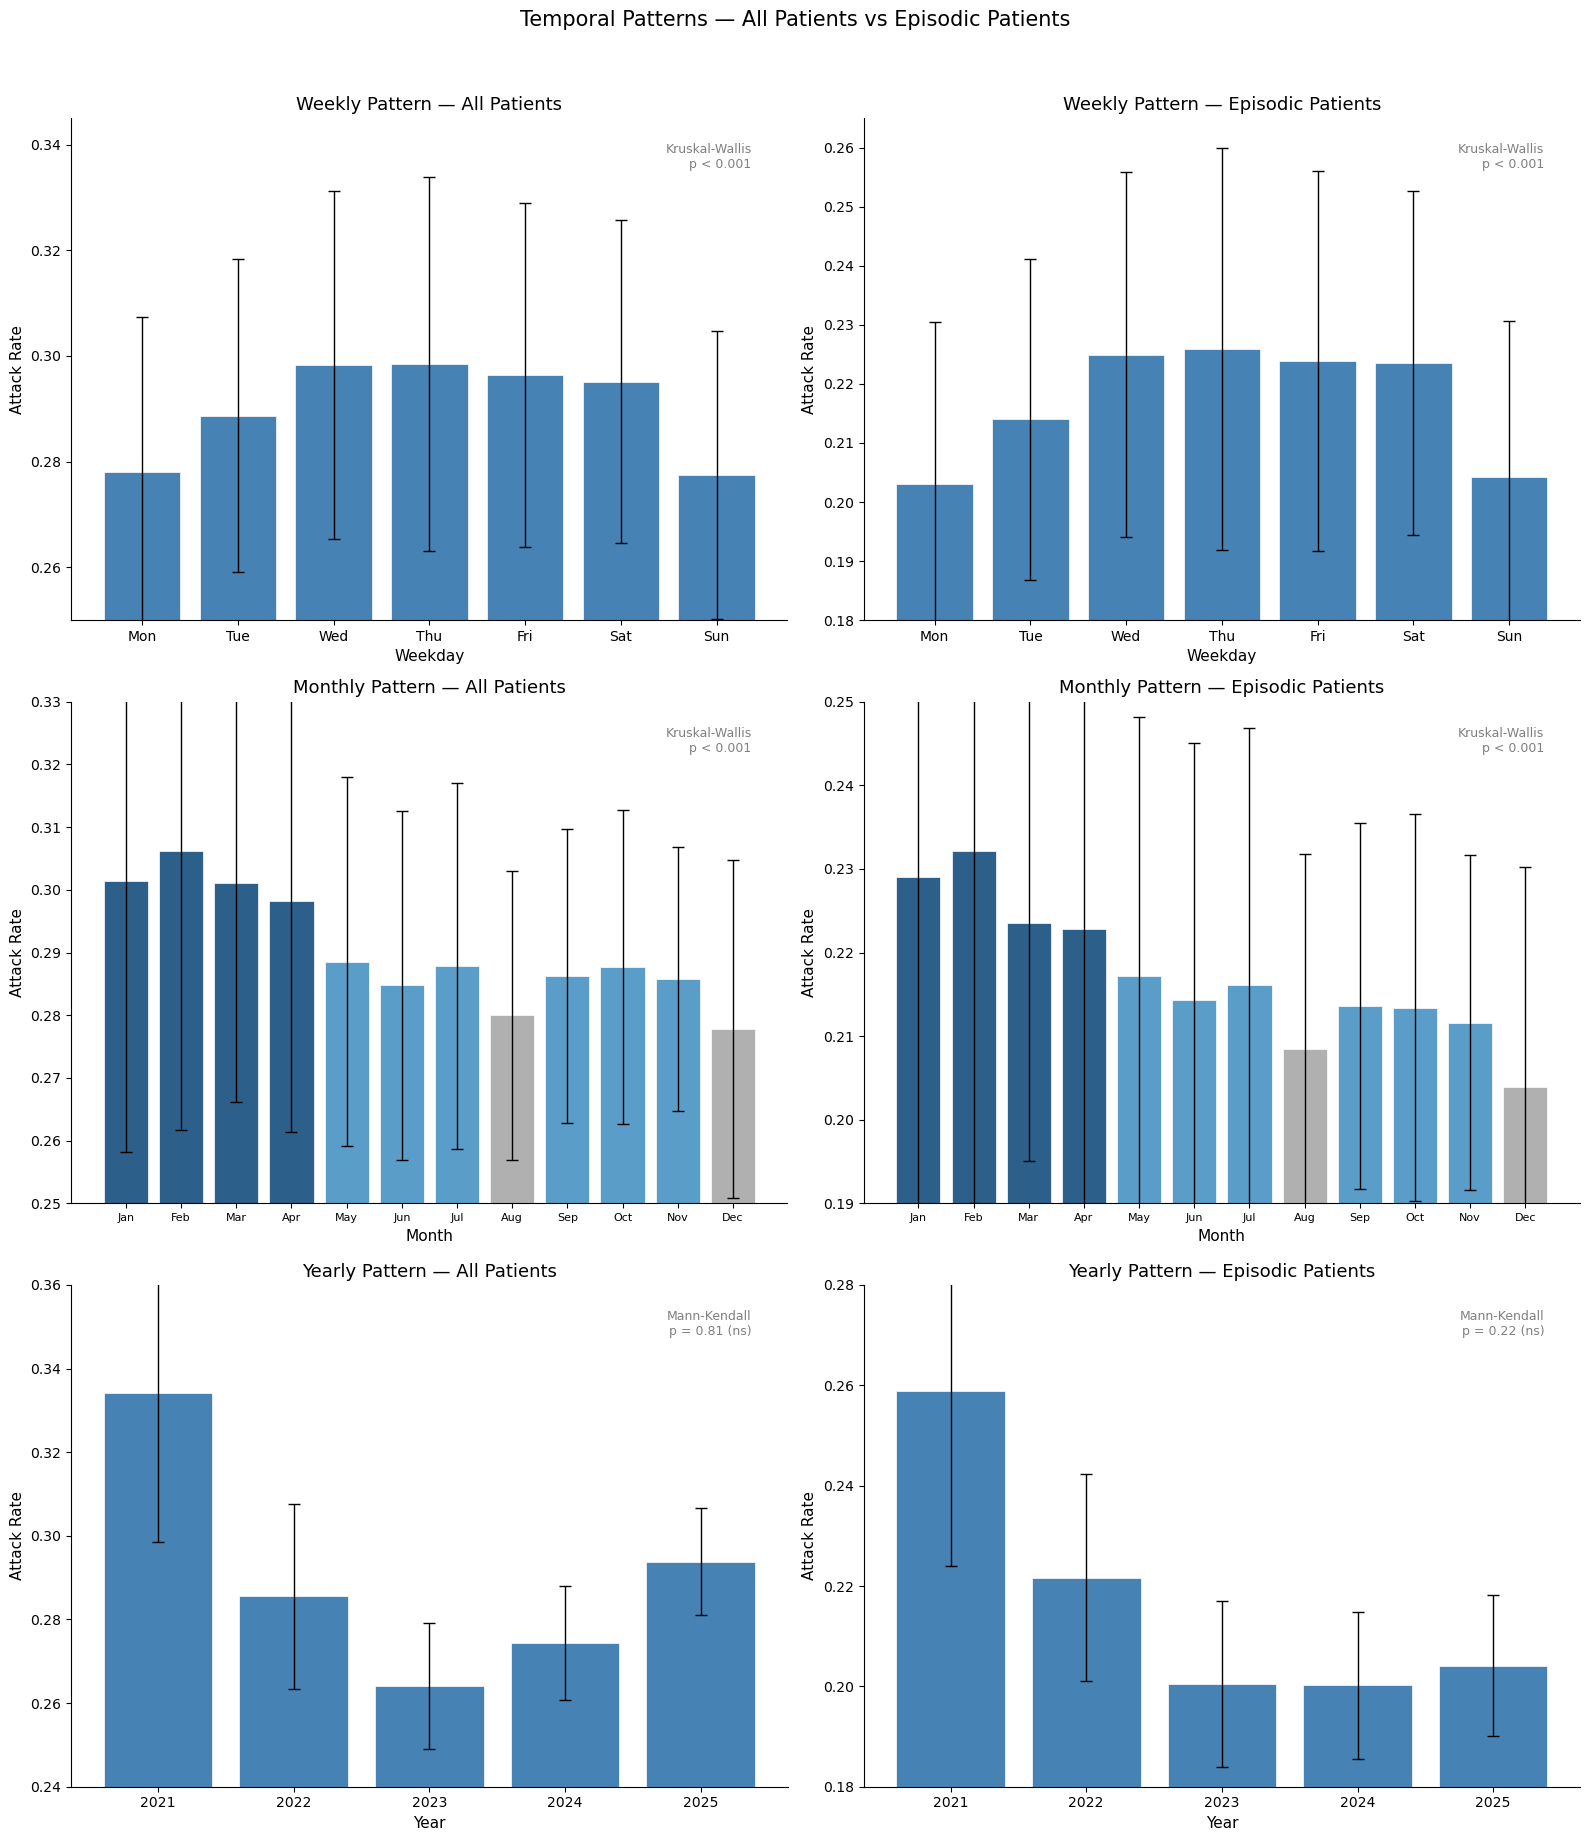

In [75]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
years = [2021, 2022, 2023, 2024, 2025]
colors_monthly = ['#2c5f8a', '#2c5f8a', '#2c5f8a', '#2c5f8a',
                  '#5b9dc9', '#5b9dc9', '#5b9dc9',
                  '#b0b0b0',
                  '#5b9dc9', '#5b9dc9', '#5b9dc9',
                  '#b0b0b0']

# ── Weekly All ────────────────────────────────────────
axes[0, 0].bar(days, weekly_mean_all.values,
               yerr=weekly_std_all.values,
               capsize=4, color='steelblue',
               edgecolor='white', linewidth=0.5,
               error_kw={'linewidth': 1, 'color': 'gray'})
axes[0, 0].set_ylim(0.25, 0.345)
axes[0, 0].set_title('Weekly Pattern — All Patients', fontsize=13)
axes[0, 0].set_xlabel('Weekday', fontsize=11)
axes[0, 0].set_ylabel('Attack Rate', fontsize=11)
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)
axes[0, 0].text(0.95, 0.95, 'Kruskal-Wallis\np < 0.001',
                transform=axes[0, 0].transAxes,
                ha='right', va='top', fontsize=9, color='gray')

# ── Weekly Episodic ───────────────────────────────────
axes[0, 1].bar(days, weekly_mean_ep.values,
               yerr=weekly_std_ep.values,
               capsize=4, color='steelblue',
               edgecolor='white', linewidth=0.5,
               error_kw={'linewidth': 1, 'color': 'gray'})
axes[0, 1].set_ylim(0.18, 0.265)
axes[0, 1].set_title('Weekly Pattern — Episodic Patients', fontsize=13)
axes[0, 1].set_xlabel('Weekday', fontsize=11)
axes[0, 1].set_ylabel('Attack Rate', fontsize=11)
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)
axes[0, 1].text(0.95, 0.95, 'Kruskal-Wallis\np < 0.001',
                transform=axes[0, 1].transAxes,
                ha='right', va='top', fontsize=9, color='gray')

# ── Monthly All ───────────────────────────────────────
axes[1, 0].bar(months, monthly_mean_all.values,
               yerr=monthly_std_all.values,
               capsize=4, color=colors_monthly,
               edgecolor='white', linewidth=0.5,
               error_kw={'linewidth': 1, 'color': 'gray'})
axes[1, 0].set_ylim(0.25, 0.330)
axes[1, 0].set_title('Monthly Pattern — All Patients', fontsize=13)
axes[1, 0].set_xlabel('Month', fontsize=11)
axes[1, 0].set_ylabel('Attack Rate', fontsize=11)
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)
axes[1, 0].tick_params(axis='x', labelsize=8)
axes[1, 0].text(0.95, 0.95, 'Kruskal-Wallis\np < 0.001',
                transform=axes[1, 0].transAxes,
                ha='right', va='top', fontsize=9, color='gray')

# ── Monthly Episodic ──────────────────────────────────
axes[1, 1].bar(months, monthly_mean_ep.values,
               yerr=monthly_std_ep.values,
               capsize=4, color=colors_monthly,
               edgecolor='white', linewidth=0.5,
               error_kw={'linewidth': 1, 'color': 'gray'})
axes[1, 1].set_ylim(0.19, 0.250)
axes[1, 1].set_title('Monthly Pattern — Episodic Patients', fontsize=13)
axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Attack Rate', fontsize=11)
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)
axes[1, 1].tick_params(axis='x', labelsize=8)
axes[1, 1].text(0.95, 0.95, 'Kruskal-Wallis\np < 0.001',
                transform=axes[1, 1].transAxes,
                ha='right', va='top', fontsize=9, color='gray')

# ── Yearly All ────────────────────────────────────────
axes[2, 0].bar(years, yearly_mean_all.values,
               yerr=yearly_std_all.values,
               capsize=4, color='steelblue',
               edgecolor='white', linewidth=0.5,
               error_kw={'linewidth': 1, 'color': 'gray'})
axes[2, 0].set_ylim(0.24, 0.360)
axes[2, 0].set_title('Yearly Pattern — All Patients', fontsize=13)
axes[2, 0].set_xlabel('Year', fontsize=11)
axes[2, 0].set_ylabel('Attack Rate', fontsize=11)
axes[2, 0].spines['top'].set_visible(False)
axes[2, 0].spines['right'].set_visible(False)
axes[2, 0].set_xticks(years)
axes[2, 0].text(0.95, 0.95, 'Mann-Kendall\np = 0.81 (ns)',
                transform=axes[2, 0].transAxes,
                ha='right', va='top', fontsize=9, color='gray')

# ── Yearly Episodic ───────────────────────────────────
axes[2, 1].bar(years, yearly_mean_ep.values,
               yerr=yearly_std_ep.values,
               capsize=4, color='steelblue',
               edgecolor='white', linewidth=0.5,
               error_kw={'linewidth': 1, 'color': 'gray'})
axes[2, 1].set_ylim(0.18, 0.280)
axes[2, 1].set_title('Yearly Pattern — Episodic Patients', fontsize=13)
axes[2, 1].set_xlabel('Year', fontsize=11)
axes[2, 1].set_ylabel('Attack Rate', fontsize=11)
axes[2, 1].spines['top'].set_visible(False)
axes[2, 1].spines['right'].set_visible(False)
axes[2, 1].set_xticks(years)
axes[2, 1].text(0.95, 0.95, 'Mann-Kendall\np = 0.22 (ns)',
                transform=axes[2, 1].transAxes,
                ha='right', va='top', fontsize=9, color='gray')

plt.suptitle('Temporal Patterns — All Patients vs Episodic Patients',
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()